In [4]:
import torch
from torch import nn, optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
import os

# 设置设备
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"当前设备: {device}")

# 数据预处理
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),  # 预训练模型需要 224x224 输入
    transforms.RandomHorizontalFlip(),  # 随机水平翻转（数据增强）
    transforms.RandomRotation(15),  # 随机旋转 ±15 度
    transforms.ColorJitter(brightness=0.2, contrast=0.2),  # 亮度/对比度变化
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # ImageNet 统计的均值和标准差
                         std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# 如果本地没有数据，会自动下载
# 方式一：直接使用 PlantVillage 的彩色叶片数据集
data_dir = './data/PlantVillage'

# 如果数据还没下载，使用 torchvision 内置的简化版本（或用下面的手动下载代码）
try:
    full_dataset = datasets.ImageFolder(root=data_dir, transform=train_transform)
    print(f"成功加载本地数据，共 {len(full_dataset)} 张图片")
except FileNotFoundError:
    print("数据不存在，请查看下方的手动下载说明")
    raise

# 查看类别
class_names = full_dataset.classes
print(f"类别数量: {len(class_names)}")
print(f"类别名称: {class_names}")
print(f"每类图片数: {dict(zip(class_names, [len([1 for _, y in full_dataset if y == i]) for i in range(len(class_names))]))}")

当前设备: cuda
成功加载本地数据，共 6625 张图片
类别数量: 4
类别名称: ['Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___healthy']
每类图片数: {'Tomato___Bacterial_spot': 2127, 'Tomato___Early_blight': 1000, 'Tomato___Late_blight': 1907, 'Tomato___healthy': 1591}


In [5]:
# 80% 训练，20% 验证
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])
# 验证集用 test_transform（不做数据增强）
val_dataset.dataset.transform = test_transform
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
print(f"训练集: {train_size} 张")
print(f"验证集: {val_size} 张")

训练集: 5300 张
验证集: 1325 张


In [6]:
# 重新加载预训练模型
model_ft = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# 冻结前几层（底层特征：边缘、纹理等通用特征）
for name, param in model_ft.named_parameters():
    if 'layer4' not in name and 'fc' not in name:  # 只解冻 layer4 和 fc
        param.requires_grad = False

num_classes = len(class_names)
model_ft.fc = nn.Linear(model_ft.fc.in_features, num_classes)

# 统计可训练参数
trainable_params = [p for p in model_ft.parameters() if p.requires_grad]
print(f"可训练参数: {sum(p.numel() for p in trainable_params):,}")
print(f"总参数: {sum(p.numel() for p in model_ft.parameters()):,}")
print(f"可训练比例: {sum(p.numel() for p in trainable_params) / sum(p.numel() for p in model_ft.parameters()) * 100:.1f}%")

model_ft = model_ft.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam([
    {'params': model_ft.layer4.parameters(), 'lr': 0.0001},  # 微调层用更小学习率
    {'params': model_ft.fc.parameters(), 'lr': 0.001}        # 分类头用正常学习率
], lr=0.001)

可训练参数: 8,395,780
总参数: 11,178,564
可训练比例: 75.1%


In [7]:
epochs = 5
ft_train_losses, ft_val_accs = [], []

for epoch in range(epochs):
    model_ft.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model_ft(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    model_ft.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model_ft(images)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

    avg_loss = running_loss / len(train_loader)
    val_acc = 100. * correct / total
    ft_train_losses.append(avg_loss)
    ft_val_accs.append(val_acc)
    print(f"Epoch [{epoch+1}/{epochs}] | Loss: {avg_loss:.4f} | Val Acc: {val_acc:.2f}%")

Epoch [1/5] | Loss: 0.1458 | Val Acc: 97.89%
Epoch [2/5] | Loss: 0.0166 | Val Acc: 98.94%
Epoch [3/5] | Loss: 0.0064 | Val Acc: 98.64%
Epoch [4/5] | Loss: 0.0087 | Val Acc: 98.42%
Epoch [5/5] | Loss: 0.0030 | Val Acc: 98.87%


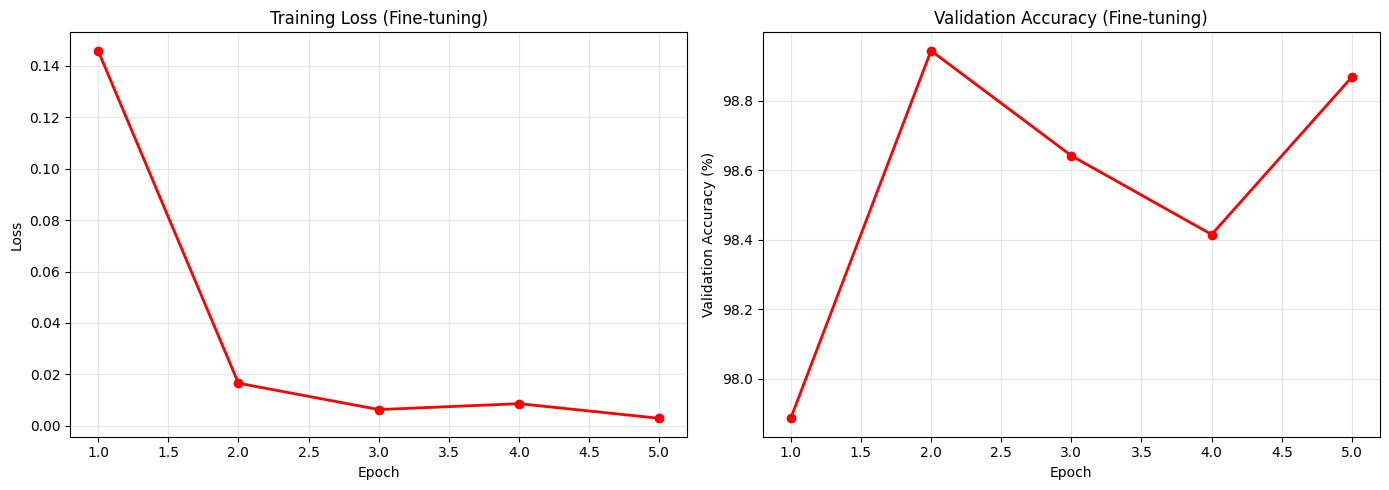

微调最佳验证准确率: 98.94%


In [9]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# 训练损失曲线
ax[0].plot(range(1, epochs+1), ft_train_losses, 'ro-', linewidth=2)
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[0].set_title('Training Loss (Fine-tuning)')
ax[0].grid(True, alpha=0.3)

# 验证准确率曲线
ax[1].plot(range(1, epochs+1), ft_val_accs, 'ro-', linewidth=2)
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Validation Accuracy (%)')
ax[1].set_title('Validation Accuracy (Fine-tuning)')
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('task_b_finetuning.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"微调最佳验证准确率: {max(ft_val_accs):.2f}%")